# 01. 전력망을 계산 문제로 바꾸기

**목표**
- 물리적인 전력망을 계산 가능한 수식으로 바꾼다.
- bus/branch/generator/load가 `Ybus`, `Sbus`, `V`로 압축되는 과정을 본다.
- 이후 Newton-Raphson이 풀 방정식의 형태를 고정한다.

**전력조류 계산이 찾는 것**
- 입력: 계통 topology, 선로 admittance, 발전/부하 조건, 일부 bus의 전압 조건
- 미지수: 각 bus의 복소 전압 `V`
- 출력: 전압을 바탕으로 계산되는 선로 전류, 손실, 과부하, 발전기 무효전력

**핵심 방정식**
$$
S_{calc}(V) = V \odot \overline{Y_{bus}V}
$$

- `Ybus`: branch/transformer 연결과 admittance를 모은 sparse matrix
- `V`: 각 bus의 복소 전압
- `S_spec`: 발전과 부하로부터 정해진 net complex power injection
- power flow: `F(V) = S_calc(V) - S_spec = 0`이 되도록 `V`를 찾는 문제

**case9를 쓰는 이유**
- bus와 branch 수가 작아서 topology와 matrix의 대응 관계를 눈으로 확인하기 쉽다.
- 성능 비교가 아니라 문제 정의를 이해하기 위한 예제다.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)


In [2]:
case = tu.load_case('case9')
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, branches={case.branch.shape[0]}, ybus_nnz={case.ybus.nnz}")
display(pd.DataFrame([
    {'object': 'bus', 'in calculation': 'one row/column of Ybus and one voltage V_i'},
    {'object': 'branch / transformer', 'in calculation': 'off-diagonal admittance and diagonal self admittance'},
    {'object': 'generator', 'in calculation': 'positive P/Q contribution to S_spec'},
    {'object': 'load', 'in calculation': 'negative P/Q contribution to S_spec'},
]))


case=case9, buses=9, branches=9, ybus_nnz=27


,object,in calculation
0,bus,one row/column of Ybus and one voltage V_i
1,branch / transformer,off-diagonal admittance and diagonal self admittance
2,generator,positive P/Q contribution to S_spec
3,load,negative P/Q contribution to S_spec


**Topology 그림에서 볼 것**
- Slack bus: 기준 전압 각도를 잡는다.
- PV bus: active power와 voltage magnitude가 지정된다.
- PQ bus: active/reactive power injection이 지정된다.
- bus type은 Newton에서 어떤 항목을 미지수로 둘지 결정한다.


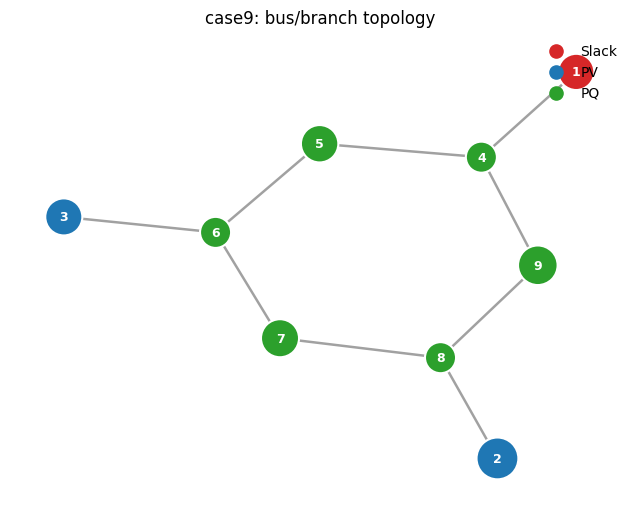

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
tu.plot_case_graph(case, ax)
plt.tight_layout()


**Topology가 sparse matrix로 바뀌는 지점**
- 계산기는 계통을 graph 그림이 아니라 `Ybus` sparse matrix로 본다.
- `Ybus[i, j] != 0`은 bus `j` 전압이 bus `i` 전류 계산에 영향을 준다는 뜻이다.
- 대형 계통에서 병목이 dense 연산이 아니라 sparse assembly/solve에 묶이는 이유가 여기서 시작된다.


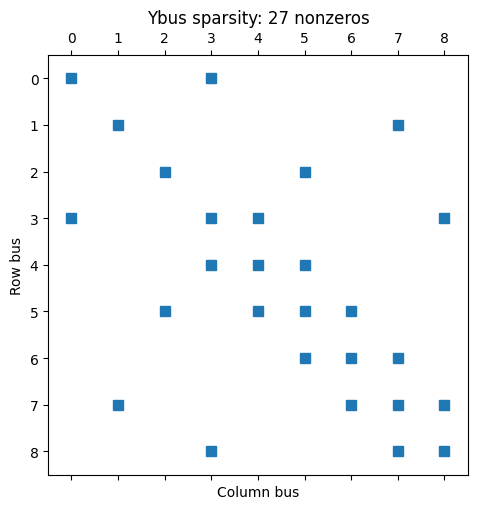

In [4]:
fig, ax = plt.subplots(figsize=(5.8, 5.2))
tu.plot_ybus(case, ax)
plt.tight_layout()


**초기 전압에서 mismatch 확인**
- `V0`는 아직 정답이 아니다.
- 그래서 `S_calc(V0)`와 `S_spec`이 다르다.
- 이 차이가 다음 노트북에서 Newton-Raphson이 줄일 대상이다.


In [5]:
snap = tu.power_flow_snapshot(case, case.v0)
print(f"reduced mismatch length={snap.mismatch_reduced.size}, inf_norm={np.linalg.norm(snap.mismatch_reduced, np.inf):.3e}")
display(tu.power_flow_bus_table(snap, limit=9).round(6))


reduced mismatch length=14, inf_norm=1.630e+00


,bus,|V|,Va_deg,P_spec,Q_spec,P_calc,Q_calc,P_mis,Q_mis
0,1,1.040,0.0,0.723,0.2703,0.0,0.722222,-0.723,0.451922
1,2,1.025,0.0,1.630,0.0654,0.0,0.410000,-1.630,0.344600
2,3,1.025,0.0,0.850,-0.1095,0.0,0.437287,-0.850,0.546787
3,4,1.000,0.0,0.000,0.0000,-0.0,-0.861444,-0.000,-0.861444
4,5,1.000,0.0,-0.900,-0.3000,0.0,-0.258000,0.900,0.042000
5,6,1.000,0.0,0.000,0.0000,0.0,-0.710121,0.000,-0.710121
6,7,1.000,0.0,-1.000,-0.3500,0.0,-0.179000,1.000,0.171000
7,8,1.000,0.0,0.000,0.0000,-0.0,-0.627500,-0.000,-0.627500
8,9,1.000,0.0,-1.250,-0.5000,0.0,-0.241000,1.250,0.259000


**다음 단계로 넘어가기 전 정리**
- `V`가 바뀌면 `S_calc(V)`도 비선형으로 바뀐다.
- 한 번의 선형 solve로 끝나지 않는다.
- Newton-Raphson은 현재 `V` 주변에서 선형화하고, mismatch가 작아질 때까지 반복한다.
